In [176]:
import pandas as pd
import bs4 as bs
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import requests



In [177]:
def get_real_value(nominal_amt, old_cpi, new_cpi):
    real_value = (nominal_amt * new_cpi) / old_cpi
    return real_value

In [178]:
url = "https://www.usinflationcalculator.com/inflation/consumer-price-index-and-annual-percent-changes-from-1913-to-2008/"

r = requests.get(url)
data = r.text
soup = bs.BeautifulSoup(data, "html.parser")

table = soup.find("table")

rows = table.tbody.find_all("tr")

years = []
crips = []

for row in rows:
    year = row.find_all("td")[0].get_text()
    if year.isdigit() and int(year) < 2017:
        years.append(int(year))
        crips.append(row.find_all("td")[13].get_text())

cpi_table = pd.DataFrame({
    "year": years,
    "cpi": crips
})

cpi_table

,year,cpi
0,1913,9.9
1,1914,10.0
2,1915,10.1
3,1916,10.9
4,1917,12.8
...,...,...
99,2012,229.594
100,2013,232.957
101,2014,236.736
102,2015,237.017


In [179]:
movies_data = pd.read_csv("data_sets/Dataset1.csv")

In [180]:
movies_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   color                       5025 non-null   object 
 1   Director_Name               4872 non-null   object 
 2   num_Critic_for_reviews      4927 non-null   float64
 3   duration                    4959 non-null   float64
 4   director_Facebook_likes     4872 non-null   float64
 5   actor_3_Facebook_likes      4953 non-null   float64
 6   actor_2_name                4963 non-null   object 
 7   Actor_1_Facebook_likes      4968 non-null   float64
 8   gross                       4104 non-null   float64
 9   genres                      4974 non-null   object 
 10  actor_1_name                4968 non-null   object 
 11  movie_Title                 4974 non-null   object 
 12  num_voted_users             4974 non-null   float64
 13   cast_total_facebook_likes  4974 

In [181]:
movies_data.head()

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,actor_2_name,Actor_1_Facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000;
1,Colour,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0;
2,Colour,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000;
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000;
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0;


## Содержание датасета:
`color` - цветной или черно-белый фильм

`movie_Title` - название фильма

`genres` - жанры фильма

`duration` - продолжительность фильма в минутах

`language` - язык фильма

`country` - страна производства

`content_rating` - возрастной рейтинг

`title_year` - год выпуска фильма

`movie_imdb_link` - ссылка на страницу фильма на IMDb

`budget` - бюджет фильма

`gross` - кассовые сборы

`Director_Name` - имя режиссера

`actor_1_name`, `actor_2_name`, `actor_3_name` - имена главных актеров

`actor_1_facebook_likes`, `actor_2_facebook_likes`, `actor_3_facebook_likes`, `director_facebook_likes` - количество лайков на Facebook у актеров и режиссера

`cast_total_facebook_likes` - суммарное количество лайков всего актерского состава

`imdb_score` - рейтинг фильма на IMDb

`num_voted_users` - количество пользователей, проголосовавших за фильм

`num_user_for_reviews` - количество пользовательских рецензий

`num_critic_for_reviews` - количество рецензий от критиков

`facenumber_in_poster` - количество лиц на постере фильма

`plot_keywords` - ключевые слова сюжета

`aspect_ratio` - соотношение сторон экрана

`movie_facebook_likes` - количество лайков фильма на Facebook

Избавимся от дубликатов.

In [182]:
movies_data.duplicated().sum()

np.int64(45)

In [183]:
movies_data.drop_duplicates(inplace=True)
movies_data.duplicated().sum()

np.int64(0)

Выясним, есть ли в датасете пропуски.

In [184]:
movies_data.isna().sum()

color                          18
Director_Name                 169
num_Critic_for_reviews        114
duration                       83
director_Facebook_likes       169
actor_3_Facebook_likes         89
actor_2_name                   79
Actor_1_Facebook_likes         74
gross                         928
genres                         68
actor_1_name                   74
movie_Title                    68
num_voted_users                68
 cast_total_facebook_likes     68
actor_3_name                   89
facenumber_in_poster           81
plot_keywords                 214
movie_imdb_link                68
num_user_for_reviews           86
language                       81
country                        71
content_rating                363
budget                        544
title_year                    172
actor_2_facebook_likes         79
imdb_score                     68
aspect_ratio                  386
movie_facebook_likes;          68
dtype: int64

Прежде, чем заполнять пропуски, преобразуем типы данных для столбцов.

In [185]:
str_columns = movies_data.select_dtypes(include='object').columns
str_columns

Index(['color', 'Director_Name', 'actor_2_name', 'genres', 'actor_1_name',
       'movie_Title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link',
       'language', 'country', 'content_rating', 'movie_facebook_likes;'],
      dtype='object')

`movie_facebook_likes;` является числовым признаком - приведем его к соответствующему типу и избавимся от символа ";" в имени.

In [186]:
categorial_columns = str_columns.drop("movie_facebook_likes;")

movies_data.rename({"movie_facebook_likes;": "movie_facebook_likes"}, inplace = True, axis=1)
movies_data["movie_facebook_likes"] = movies_data["movie_facebook_likes"].str.replace(";", "")
movies_data["movie_facebook_likes"] = movies_data["movie_facebook_likes"].astype("Int64")

categorial_columns

Index(['color', 'Director_Name', 'actor_2_name', 'genres', 'actor_1_name',
       'movie_Title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link',
       'language', 'country', 'content_rating'],
      dtype='object')

Заполним пропуски в категориальных столбцах модальным значением, а в числовых столбцах - медианным.

In [187]:
for column in categorial_columns:
    movies_data[column] = movies_data[column].fillna(movies_data[column].mode()[0])

numeric_columns = movies_data.select_dtypes(include="number").columns
for column in numeric_columns:
    movies_data[column] = movies_data[column].fillna(int(movies_data[column].median()))


In [188]:
movies_data.isna().sum()

color                         0
Director_Name                 0
num_Critic_for_reviews        0
duration                      0
director_Facebook_likes       0
actor_3_Facebook_likes        0
actor_2_name                  0
Actor_1_Facebook_likes        0
gross                         0
genres                        0
actor_1_name                  0
movie_Title                   0
num_voted_users               0
 cast_total_facebook_likes    0
actor_3_name                  0
facenumber_in_poster          0
plot_keywords                 0
movie_imdb_link               0
num_user_for_reviews          0
language                      0
country                       0
content_rating                0
budget                        0
title_year                    0
actor_2_facebook_likes        0
imdb_score                    0
aspect_ratio                  0
movie_facebook_likes          0
dtype: int64

Преобразуем валовую и бюджетную стоимость в реальные суммы в долларах с
точки зрения покупательной способности 2016 г. После этого удалим информацию о старых значениях для валовой и бюджетной стоимостей, а также столбец, содержащий ссылку на страницу фильма.

In [189]:
real_domestic_gross = []
real_budget_values = []
cpi_2016 = float((cpi_table[cpi_table["year"] == 2016]["cpi"]).values[0])

for index, row in movies_data.iterrows():
    gross = row["gross"]
    budget = row["budget"]
    year = row["title_year"]
    cpi = float(cpi_table[ cpi_table["year"] == year ]["cpi"].values[0])

    real_gross = get_real_value(gross, cpi, cpi_2016)
    real_budget = get_real_value(budget, cpi, cpi_2016)
    real_domestic_gross.append(real_gross)
    real_budget_values.append(real_budget)

movies_data["real_domestic_gross"] = real_domestic_gross
movies_data["real_budget"] = real_budget_values
movies_data.drop(["gross", "budget", "movie_imdb_link"], axis=1, inplace=True)
movies_data

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,actor_2_name,Actor_1_Facebook_likes,genres,actor_1_name,...,language,country,content_rating,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,real_domestic_gross,real_budget
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,...,English,USA,PG-13,2009.0,936.0,7.9,1.78,33000,8.507937e+08,2.651368e+08
1,Colour,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,Action|Adventure|Fantasy,Johnny Depp,...,English,USA,PG-13,2007.0,5000.0,7.1,2.35,0,3.582208e+08,3.473329e+08
2,Colour,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,Action|Adventure|Thriller,Christoph Waltz,...,English,UK,PG-13,2015.0,393.0,6.8,2.35,85000,2.025981e+08,2.480907e+08
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,Action|Thriller,Tom Hardy,...,English,USA,PG-13,2012.0,23000.0,8.5,2.35,164000,4.684551e+08,2.613385e+08
4,Color,Doug Walker,110.0,103.0,131.0,372.0,Rob Walker,131.0,Documentary,Doug Walker,...,English,USA,R,2005.0,12.0,7.1,2.00,0,3.137380e+07,2.457829e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,637.0,Comedy|Drama,Eric Mabius,...,English,Canada,R,2013.0,470.0,7.7,2.00,84,2.630230e+07,2.060526e+07
5039,Color,Steven Spielberg,43.0,43.0,49.0,319.0,Valorie Curry,841.0,Crime|Drama|Mystery|Thriller,Natalie Zea,...,English,USA,TV-14,2005.0,593.0,7.5,16.00,32000,3.137380e+07,2.457829e+07
5040,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,0.0,Drama|Horror|Thriller,Eva Boehnke,...,English,USA,R,2013.0,0.0,6.3,2.00,16,2.630230e+07,1.442368e+03
5041,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,946.0,Comedy|Drama|Romance,Alan Ruck,...,English,USA,PG-13,2012.0,719.0,6.3,2.35,660,1.091663e+04,2.090708e+07


## Статистическая информация

In [190]:
movies_data.describe()

,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,Actor_1_Facebook_likes,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,real_domestic_gross,real_budget
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4.998000e+03,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.0,4.998000e+03,4.998000e+03
mean,139.569828,107.134054,671.668467,637.690076,6486.546819,8.294089e+04,9615.149860,1.364346,270.765106,2002.574230,1634.262305,6.432533,2.207099,7431.82593,6.793342e+07,4.894159e+07
std,120.413150,24.823597,2784.381897,1636.346970,15020.428505,1.374407e+05,18120.826801,2.002276,375.564051,12.225484,4014.190994,1.116391,1.345491,19278.524171,1.232866e+08,2.391459e+08
min,1.000000,7.000000,0.000000,0.000000,0.000000,5.000000e+00,0.000000,0.000000,1.000000,1916.000000,0.000000,1.600000,1.180000,0.0,1.642384e+02,2.843561e+02
25%,51.000000,93.000000,8.000000,138.250000,624.000000,8.915750e+03,1440.000000,0.000000,67.000000,1999.000000,288.250000,5.800000,1.850000,0.0,1.192644e+07,1.115061e+07
50%,110.000000,103.000000,49.000000,372.000000,989.000000,3.444200e+04,3089.000000,1.000000,156.000000,2005.000000,595.000000,6.500000,2.000000,162.0,3.137380e+07,2.457829e+07
75%,192.000000,117.000000,188.000000,631.000000,11000.000000,9.437825e+04,13624.250000,2.000000,322.000000,2010.000000,912.000000,7.200000,2.350000,3000.0,7.785450e+07,5.471662e+07
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,1.689764e+06,656730.000000,43.000000,5060.000000,2016.000000,137000.000000,9.500000,16.000000,349000.0,3.430119e+09,1.454269e+10


`num_Critic_for_reviews`

Среднее значение — 139.6, медиана — 110, минимум — 1, максимум — 813.

В среднем фильмы получают примерно 100 отзывов от критиков, но при этом есть фильмы, которые критики практически не рассматривали (1 отзыв) и фильмы, которым критики уделяли особо много внимания (813 отзывов).

`duration`

Среднее — 107 минут, медиана — 103, минимум - 7 минут, максимум - 511 минут.

В целом фильмы идут около 1.5 часов, но при этом есть и особо короткие фильмы, и очень длинные.

`director_facebook_likes`

Среднее — 672, медиана — 49, минимум - 0, максимум - 23 000.

В целом режиссеры получают небольшое количество лайков, но при этом есть и особо популярные.

`actor_3_facebook_likes`

Среднее — 638, медиана — 372, минимум - 0, максимум - 23 000.

Актеры третьего плана более популярны в социальных сетях, чем режиссеры. При этом есть как и малоизвестные актеры, так и особо популярные.

`actor_2_facebook_likes`
Среднее — 1634, медиана — 595, минимум - 0, максимум - 137 000.

Актеры второго плана более популярны, чем актеры третьего планы и режиссеры. При этом есть как и малоизвестные актеры, так и особо популярные.

`actor_1_facebook_likes`

Среднее — 6487, медиана — 989, минимум - 0, максимум - 640 000.
В среднем актеры первого плана более популярны, чем другие актеры и режиссеры. При этом есть как и малоизвестные актеры, так и особо популярные.

`num_voted_users`

Среднее — 82 941, медиана — 34 442, минимум - 5, максимум - 1.69 млн.

Есть сильная правосторонняя асимметрия. В среднем фильмы получают около 35 тысяч голосов, но есть и особо популярные фильмы.

`cast_total_facebook_likes`

Среднее — 9615, медиана — 3089, минимум - 0, максимум - 656 730.

Есть сильная правосторонняя асимметрия. Есть особо популярные составы, есть малоизвестные.

`facenumber_in_poster`

Среднее — 1.36, медиана — 1, минимум - 0, максимум - 43.

В среднем на постере изображен один человек, но есть постеры с большим составом.

`num_user_for_reviews`

Среднее — 271, медиана — 156, минимум - 1, максимум - 5060.

В среднем фильмы получают около 150-200 отзывов, но есть и особо обсуждаемые картины.

`title_year`

Среднее — 2002.6, медиана — 2005, от 1916 до 2016.

Большая часть фильмов вышла в начале двухтысячных, но есть и более старые, и более новые фильмы.

`imdb_score`

Среднее — 6.43, медиана — 6.5, минимум - 1.6, максимум - 9.5.

В целом фильмы получают оценку около 6-7 баллов, но есть и плохие картины с низкими оценками, и высоко оцененные картины с высокими оценками.

`aspect_ratio`

Среднее — 2.21, медиана — 2.0, минимум - 1.18, максимум - 16.

В целом картины обладают стандартным соотношением сторон, но есть картины с нестандартным соотношением.

`movie_facebook_likes`

Среднее — 7432, медиана — 162, минимум - 0, максимум - 349 000.

В целом картины собирают немного лайков в социальных сетях, но есть особо популярные фильмы.

`real_domestic_gross`

Среднее — 67.9 млн, медиана — 31.4 млн, минимум - 164 тыс., максимум - 3.43 млрд.

Есть фильмы, собравшие маленькие суммы в прокате, и есть фильмы, которые имеют особо большие кассовые сборы.

`real_budget`

Среднее — 48.9 млн, медиана — 24.6 млн, минимум - 284 тыс., максимум - 14.5 млрд.

Есть как дешевые фильмы, так и особо дорогие.

array([[<Axes: title={'center': 'num_Critic_for_reviews'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'director_Facebook_likes'}>,
        <Axes: title={'center': 'actor_3_Facebook_likes'}>],
       [<Axes: title={'center': 'Actor_1_Facebook_likes'}>,
        <Axes: title={'center': 'num_voted_users'}>,
        <Axes: title={'center': ' cast_total_facebook_likes'}>,
        <Axes: title={'center': 'facenumber_in_poster'}>],
       [<Axes: title={'center': 'num_user_for_reviews'}>,
        <Axes: title={'center': 'title_year'}>,
        <Axes: title={'center': 'actor_2_facebook_likes'}>,
        <Axes: title={'center': 'imdb_score'}>],
       [<Axes: title={'center': 'aspect_ratio'}>,
        <Axes: title={'center': 'movie_facebook_likes'}>,
        <Axes: title={'center': 'real_domestic_gross'}>,
        <Axes: title={'center': 'real_budget'}>]], dtype=object)

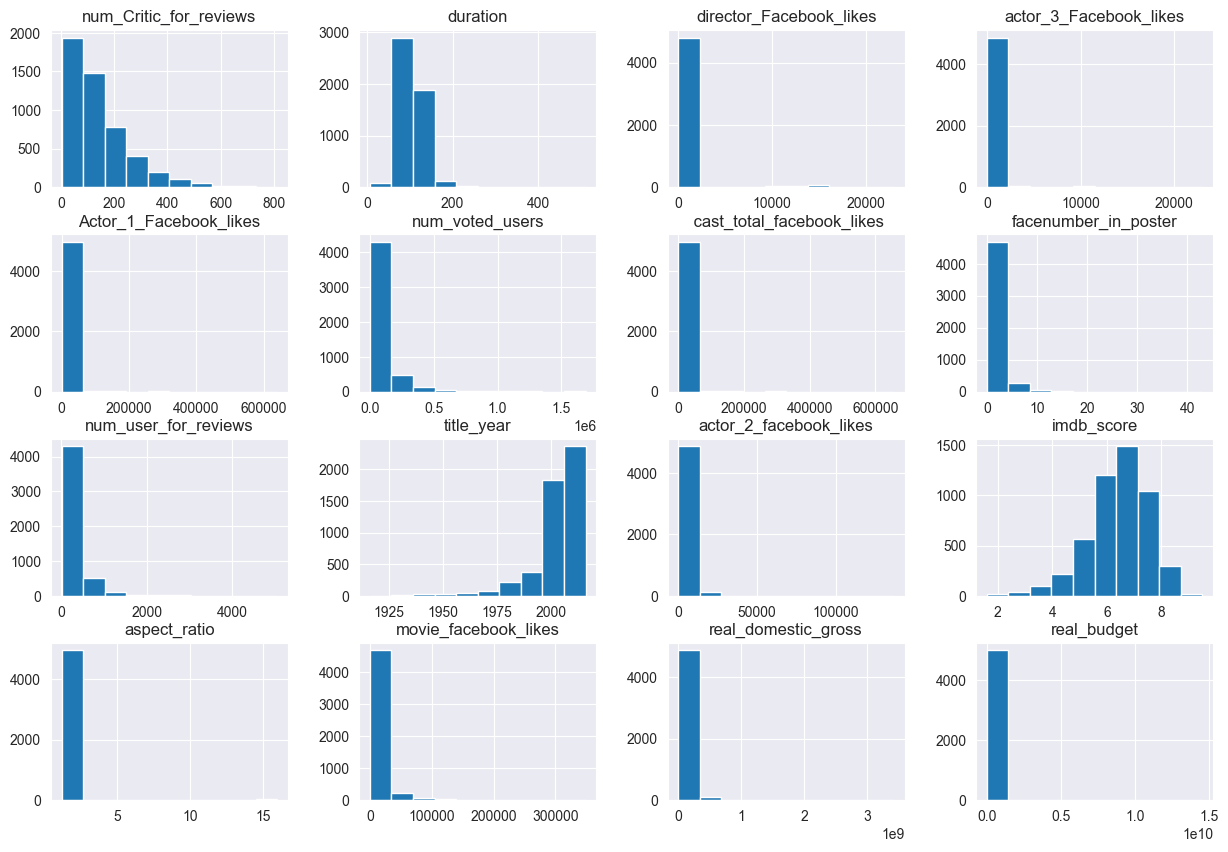

In [191]:
movies_data.hist(figsize=(15, 10))

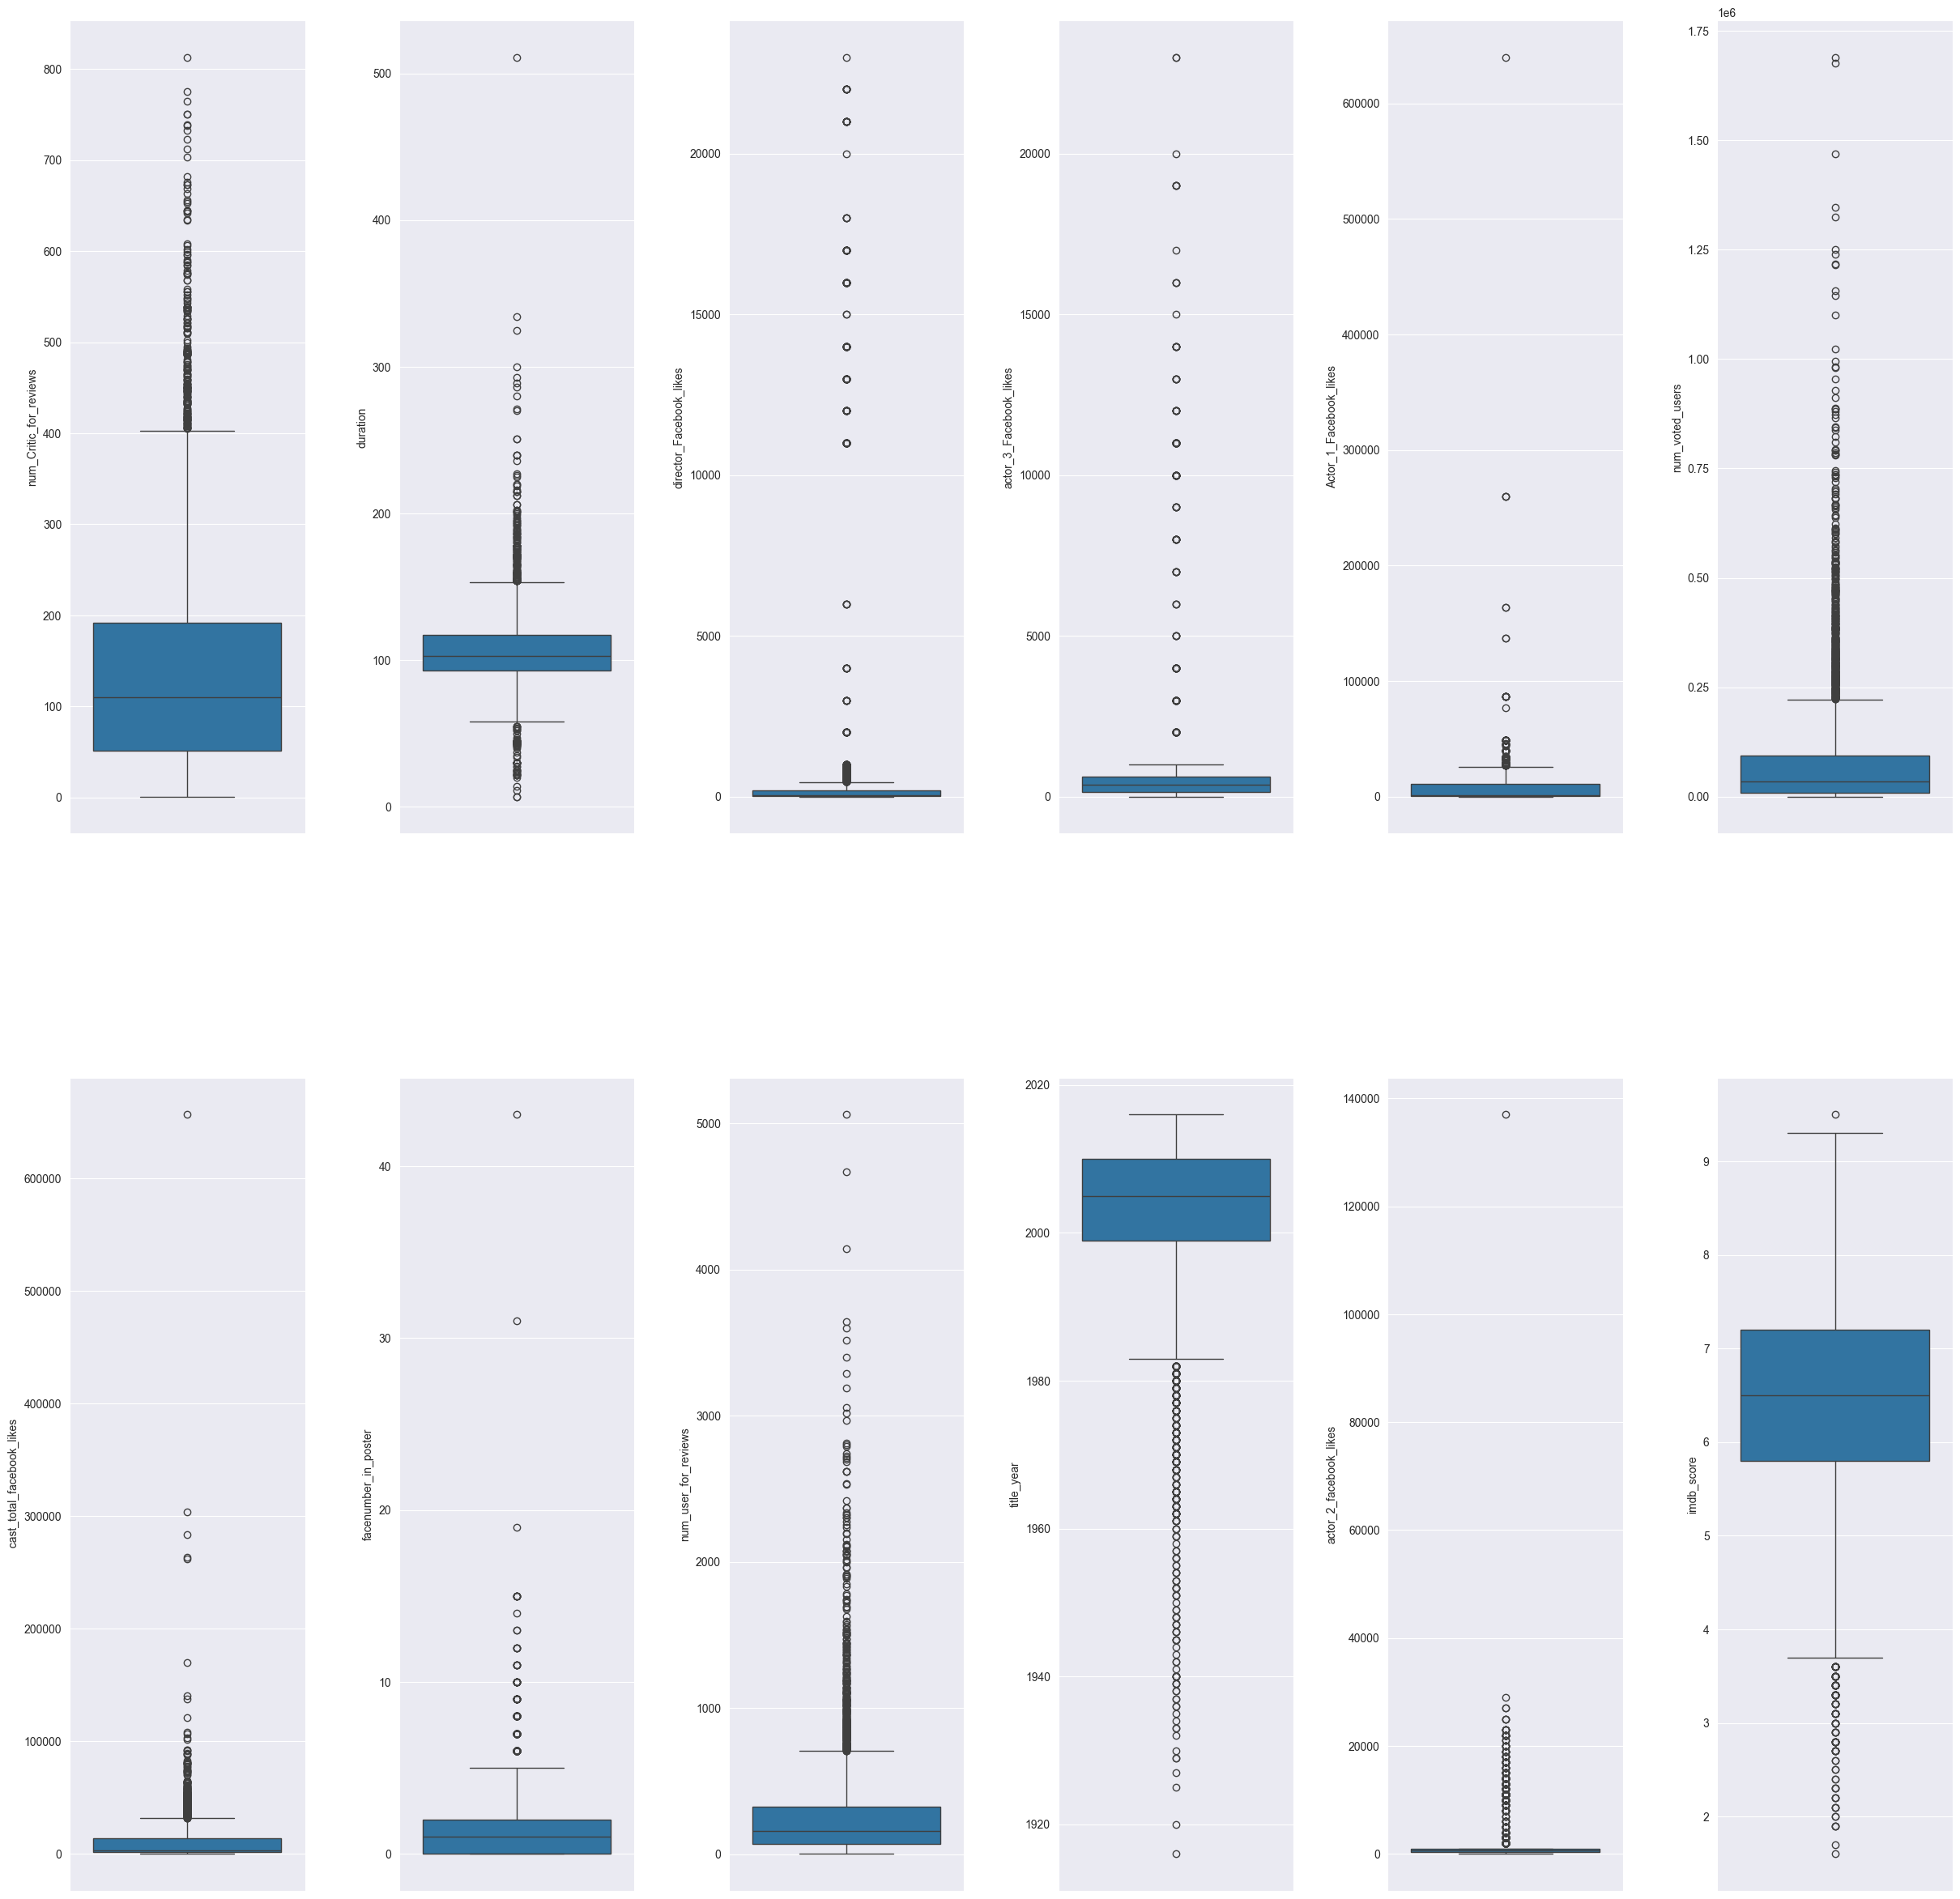

In [192]:
fig, axs = plt.subplots(2, 6, figsize=(30, 30))
plt.subplots_adjust(wspace=0.4, hspace=0.3)
ax_flatten = axs.flatten()
numeric_columns = movies_data.select_dtypes(include="number").columns
for i in range(len(ax_flatten)):
    sns.boxplot(movies_data, y = movies_data[numeric_columns[i]], ax = ax_flatten[i])

In [193]:
# numeric_data = movies_data[numeric_columns]
#
# q1 = numeric_data.quantile(0.25)
# q3 = numeric_data.quantile(0.75)
#
# IQR = q3 - q1
#
# data_filtered = numeric_data[~((numeric_data < (q1 - 1.5 * IQR)) |(numeric_data > (q3 + 1.5 * IQR))).any(axis=1)]
# data_filtered

<Axes: >

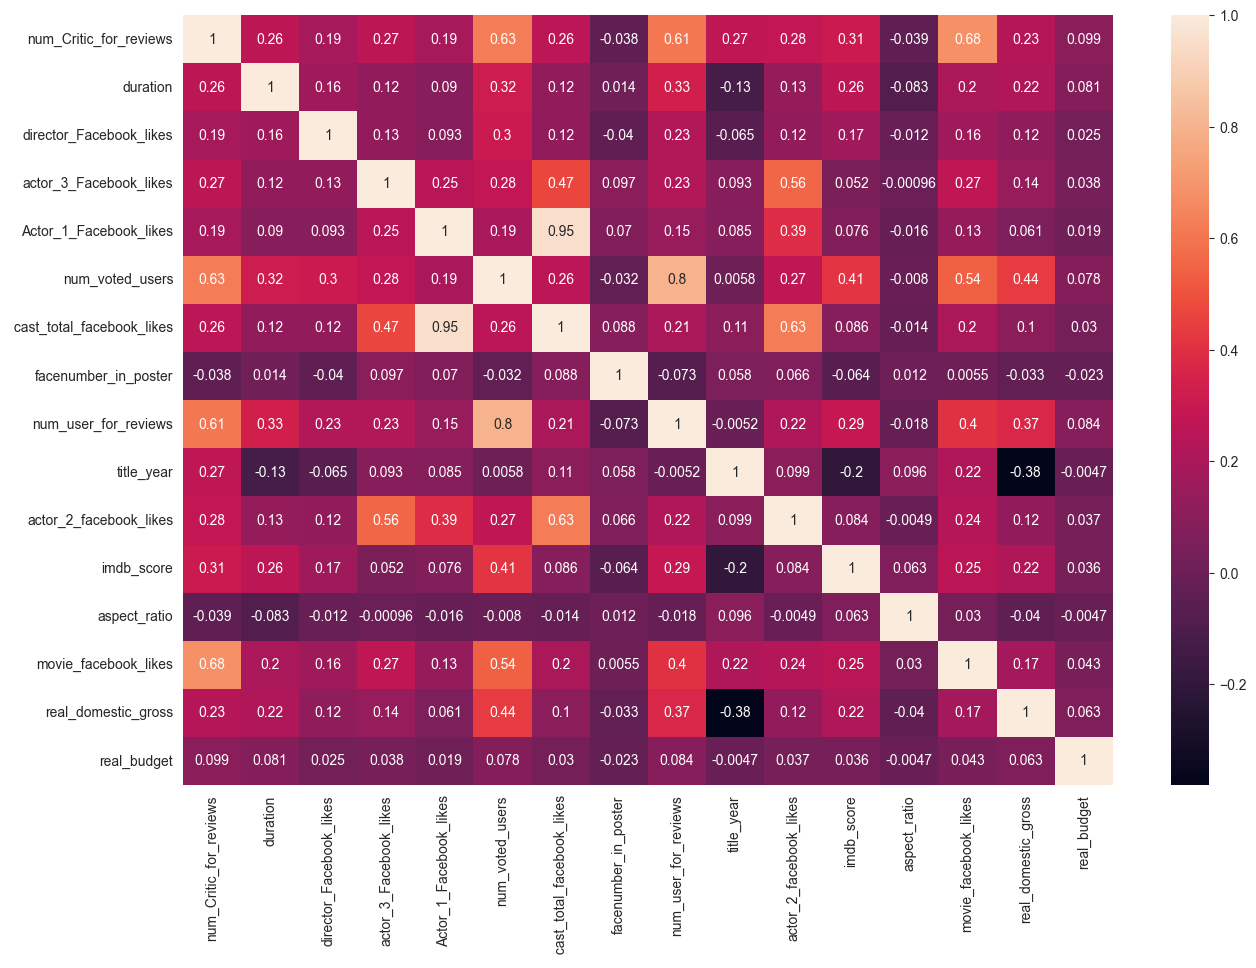

In [194]:
plt.figure(figsize=(15, 10))
sns.heatmap(movies_data[numeric_columns].corr(), annot=True)

Text(0.5, 1.0, 'Зависимость оценки от года выпуска')

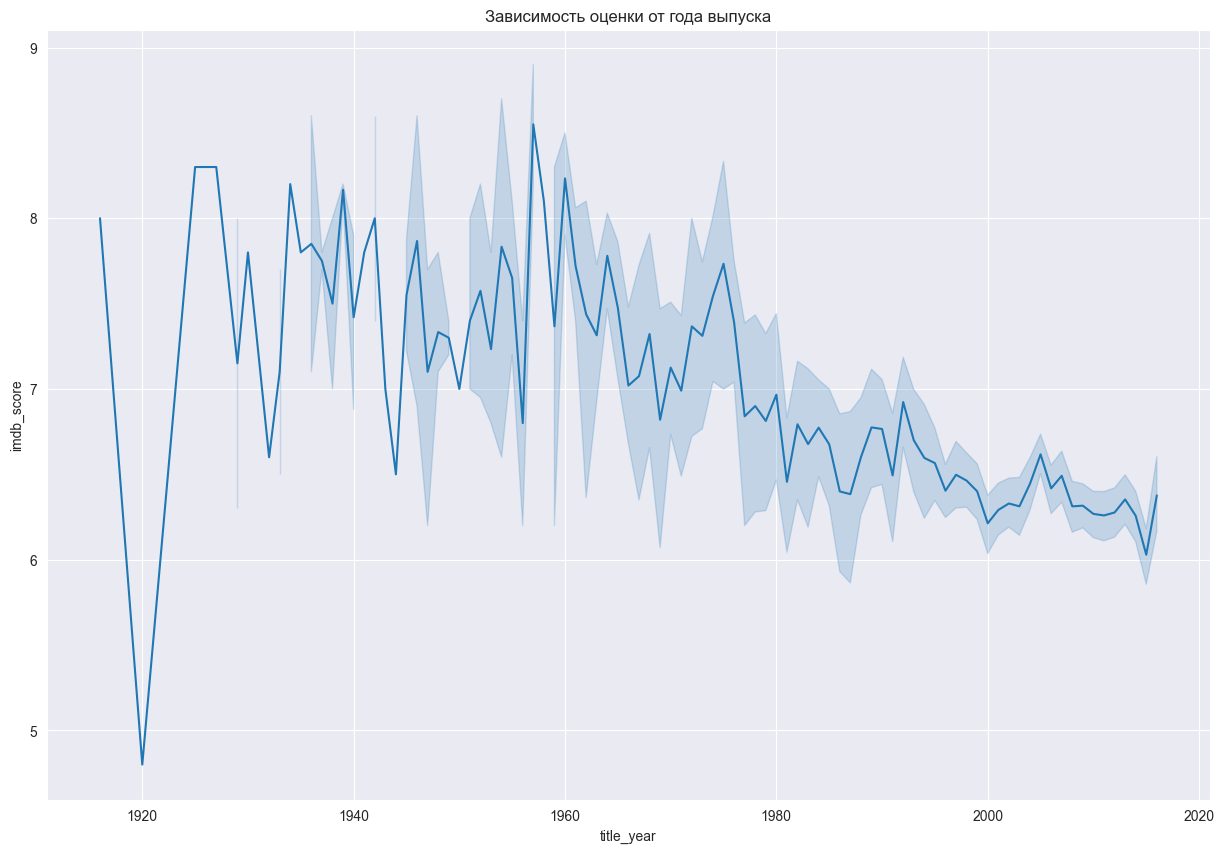

In [195]:
plt.figure(figsize=(15, 10))
sns.lineplot(movies_data, y = movies_data["imdb_score"], x=movies_data["title_year"], dashes=False)
plt.title("Зависимость оценки от года выпуска")

<Axes: xlabel='real_budget', ylabel='real_domestic_gross'>

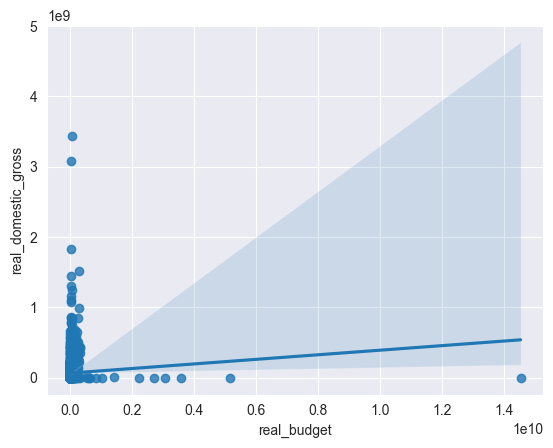

In [196]:
sns.regplot(movies_data, x=movies_data["real_budget"], y=movies_data["real_domestic_gross"])

([<matplotlib.patches.Wedge at 0x224cbaee710>,
 [Text(0.923411046295265, 0.5977558360901917, 'Drama'),
  Text(0.022023505170168833, 1.0997795075468626, 'Comedy'),
  Text(-0.6979613092437162, 0.8502058637758256, 'Thriller'),
  Text(-1.0412563083098652, 0.35466223425240956, 'Action'),
  Text(-1.0861104295765676, -0.1742530767734219, 'Romance'),
  Text(-0.9103077343494065, -0.6175271886999394, 'Adventure'),
  Text(-0.605455355545057, -0.9183810823627677, 'Crime'),
  Text(-0.2798269903503507, -1.0638124155467754, 'Sci-Fi'),
  Text(0.0077455488567498305, -1.099972729876931, 'Fantasy'),
  Text(0.2826357788458382, -1.0630696197880019, 'Horror'),
  Text(0.5264306636809146, -0.9658523470678486, 'Family'),
  Text(0.7287242823871891, -0.8239908496210843, 'Mystery'),
  Text(0.8579845127192898, -0.6883767688801266, 'Biography'),
  Text(0.9317368857206481, -0.5846934032359081, 'Animation'),
  Text(0.9848636269503563, -0.4899424826550453, 'Music'),
  Text(1.0257863112037107, -0.3971932070757055, 'War

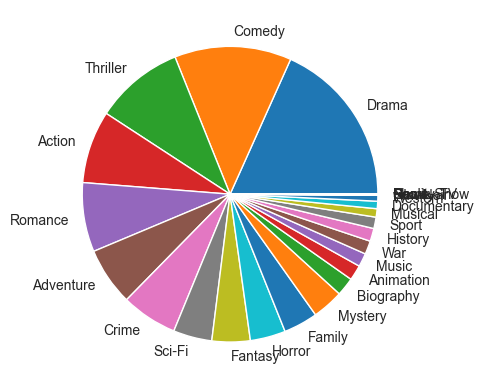

In [197]:
all_genres = movies_data["genres"].str.split('|').explode(ignore_index=True)
genres_count = all_genres.value_counts()
plt.pie(genres_count.values, labels=genres_count.index)